# STFT-CNN Sleep Stage Classification
**架构与 TimesNet notebook 完全对齐**，相同数据切分 / 相同患者分组 / 相同评估图表。

用途：作为与 TimesNet 的**频域对比实验**，输入同一套 `.npy` 文件，输出可直接比较的 Accuracy / Macro-F1 / Confusion Matrix / Hypnogram。

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3080 Laptop GPU


# 1. Pre-process

Import & Load data

In [ ]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import Counter
from scipy import signal as scipy_signal
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, cohen_kappa_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

df = pd.read_csv("dataset/S025_whole_df.csv")
df.head()


,TIMESTAMP,BVP,ACC_X,ACC_Y,ACC_Z,TEMP,EDA,HR,IBI,Sleep_Stage,Obstructive_Apnea,Central_Apnea,Hypopnea,Multiple_Events
0,0.000000,140.76,-40.0,7.0,50.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
1,0.015625,135.32,-40.0,7.0,50.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
2,0.031250,130.88,-41.0,7.0,49.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
3,0.046875,118.15,-41.0,7.0,49.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN
4,0.062500,92.38,-41.0,8.0,50.0,33.59,0.034544,60.0,NaN,P,NaN,NaN,NaN,NaN


Select features & check missing values

In [3]:
features  = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
label_col = 'Sleep_Stage'

stage_counts = df['Sleep_Stage'].value_counts(dropna=False)
print(stage_counts)

missing_before = df[features].isna().sum().sum()
print(f"Missing Before: {missing_before}")


Sleep_Stage
N2    858240
W     412801
P     406592
R     240000
N1     74880
Name: count, dtype: int64
Missing Before: 2488


Fill missing values

In [4]:
df[features] = df[features].interpolate(method='linear', limit_direction='both')
print(f"Missing After: {df[features].isna().sum().sum()}")

Missing After: 0


Data preprocess

In [ ]:

FEATURE_NAMES = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']

FAST_CHANNELS = {'BVP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR'}
SLOW_CHANNELS = {'IBI', 'EDA', 'TEMP'}

FAST_NPERSEG, FAST_NOVERLAP = 64, 32     # Δf = 64/64   = 1.0000 Hz/bin
SLOW_NPERSEG, SLOW_NOVERLAP = 1920, 0    # Δf = 64/1920 = 0.0333 Hz/bin


CHANNEL_KEEP_BINS = {
    'BVP':   12,   # 0~12 Hz   
    'ACC_X': 12,
    'ACC_Y': 12,
    'ACC_Z': 12,
    'HR':     8,   # 0~8 Hz
    'IBI':   12,   # 0~0.40 Hz 
    'EDA':   15,   # 0~0.50 Hz 
    'TEMP':   4,   # 0~0.13 Hz 
}
MAX_BINS = max(CHANNEL_KEEP_BINS.values())   


def compute_stft_window(window_2d, fs=64):
 
    n_channels = window_2d.shape[1]

    _, _, Zxx_ref = scipy_signal.stft(
        window_2d[:, 0].astype(np.float64), fs=fs, window='hamming',
        nperseg=FAST_NPERSEG, noverlap=FAST_NOVERLAP, boundary='zeros'
    )
    T = Zxx_ref.shape[1]

    spectrograms = []
    for c in range(n_channels):
        name = FEATURE_NAMES[c]
        keep = CHANNEL_KEEP_BINS[name]
        sig  = window_2d[:, c].astype(np.float64)

        if name in SLOW_CHANNELS:
            _, _, Zxx = scipy_signal.stft(
                sig, fs=fs, window='hamming',
                nperseg=SLOW_NPERSEG, noverlap=SLOW_NOVERLAP,
                boundary=None, padded=False
            )
            mag     = np.abs(Zxx[:keep, :])            # (keep, 1)
            log_mag = np.log(mag + 1e-8)
            log_mag = np.repeat(log_mag, T, axis=1)     
        else:
            _, _, Zxx = scipy_signal.stft(
                sig, fs=fs, window='hamming',
                nperseg=FAST_NPERSEG, noverlap=FAST_NOVERLAP, boundary='zeros'
            )
            mag     = np.abs(Zxx[:keep, :])             # (keep, T)
            log_mag = np.log(mag + 1e-8)

        if keep < MAX_BINS:
            pad     = np.zeros((MAX_BINS - keep, log_mag.shape[1]))
            log_mag = np.vstack([log_mag, pad])

        spectrograms.append(log_mag.astype(np.float32))

    return np.stack(spectrograms, axis=0)   # (8, MAX_BINS, T)


test_out = compute_stft_window(np.random.randn(1920, 8))
print(f"STFT output shape per window: {test_out.shape}")


STFT output shape per window: (8, 15, 61)


In [ ]:

def compute_norm_stats(X_train):

    mean = X_train.mean(axis=(0, 3), keepdims=True)   
    std  = X_train.std(axis=(0, 3), keepdims=True)
    std  = np.where(std < 1e-6, 1.0, std)             
    return mean.astype(np.float32), std.astype(np.float32)

def apply_norm(X, mean, std):
    return ((X - mean) / std).astype(np.float32)

Slice data 

In [ ]:
window_size = 1920   

def create_windows_stft(df_in, window_size=1920):
    n_samples = len(df_in) // window_size
    X_list, y_list = [], []

    for i in range(n_samples):
        s, e       = i * window_size, (i + 1) * window_size
        window_df  = df_in.iloc[s:e]
        mode_series = window_df[label_col].mode()
        if mode_series.empty:
            continue
        label = mode_series.iloc[0]
        if str(label).strip() in ['P', 'Missing']:
            continue

        raw_window = window_df[features].values          # (1920, 8)
        stft_tensor = compute_stft_window(raw_window)    # (8, 12, 59)

        X_list.append(stft_tensor)
        y_list.append(label)

    return np.array(X_list), np.array(y_list)

print("Generating STFT windows for S025 (single patient)...")
X, y = create_windows_stft(df)
print(f"X shape: {X.shape}")   # (N, 8, 12, 59)
print(f"y shape: {y.shape}")
print(f"Label sample: {y[:5]}")


Generating STFT windows for S025 (single patient)...
X shape: (825, 8, 15, 61)
y shape: (825,)
Label sample: ['W' 'W' 'W' 'W' 'W']


In [8]:
label_map = {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'R': 4}
y_encoded = np.array([label_map[l] for l in y])
print("Encoded labels:", y_encoded[:5])


Encoded labels: [0 0 0 0 0]


# 2. Single Patient Training

Split & save data

In [9]:
save_dir = './dataset/stft_data_ready/'
os.makedirs(save_dir, exist_ok=True)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp)

norm_mean, norm_std = compute_norm_stats(X_train)
X_train = apply_norm(X_train, norm_mean, norm_std)
X_val   = apply_norm(X_val,   norm_mean, norm_std)
X_test  = apply_norm(X_test,  norm_mean, norm_std)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}")

np.save(os.path.join(save_dir, 'X_train.npy'), X_train)
np.save(os.path.join(save_dir, 'y_train.npy'), y_train)
np.save(os.path.join(save_dir, 'X_val.npy'),   X_val)
np.save(os.path.join(save_dir, 'y_val.npy'),   y_val)
np.save(os.path.join(save_dir, 'X_test.npy'),  X_test)
np.save(os.path.join(save_dir, 'y_test.npy'),  y_test)
print("Saved.")


X_train: (577, 8, 15, 61)  y_train: (577,)
X_val:   (83, 8, 15, 61)  y_val:   (83,)
X_test:  (165, 8, 15, 61)  y_test:  (165,)
Saved.


Dataset & DataLoader

In [10]:
class STFTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)   # (N, 8, 12, 59)
        self.y = torch.LongTensor(y)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te, batch_size=32):
    return (
        DataLoader(STFTDataset(X_tr, y_tr), batch_size, shuffle=True),
        DataLoader(STFTDataset(X_v,  y_v),  batch_size, shuffle=False),
        DataLoader(STFTDataset(X_te, y_te), batch_size, shuffle=False),
    )

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test)
print("DataLoaders ready.")


DataLoaders ready.


## STFT-CNN Model
2D-CNN 处理时频图，结构与 TimesNet 参数量相近（约 300K），保证对比公平。

In [ ]:
class STFTSleepNet(nn.Module):
    def __init__(self, in_channels=8, num_classes=5, dropout=0.3):
        super().__init__()
        self.encoder = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # (B, 32, 6, 29)

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # (B, 64, 3, 14)

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 4)),  # (B, 128, 2, 4) 
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                  # (B, 1024)
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.encoder(x))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = STFTSleepNet().to(DEVICE)
total  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device: {DEVICE}")
print(f"Trainable parameters: {total:,}")


Device: cuda
Trainable parameters: 374,309


Weighted Loss — 与 TimesNet notebook 相同的类别不平衡处理

In [12]:
weights = torch.tensor([1.0, 2.0, 0.35, 1.1, 0.9], dtype=torch.float32)
print("[physiological-prior] W/N1/N2/N3/R =", weights.tolist())

weight_tensor = torch.FloatTensor(weights).to(DEVICE)
criterion     = nn.CrossEntropyLoss(weight=weight_tensor)

[physiological-prior] W/N1/N2/N3/R = [1.0, 2.0, 0.3499999940395355, 1.100000023841858, 0.8999999761581421]


Train

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True)

EPOCHS   = 50
PATIENCE = 10

best_val_f1  = 0
best_state   = None
patience_cnt = 0
history      = {'train_loss': [], 'val_acc': [], 'val_f1': []}

print("Starting training...")
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    #train
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    #validate 
    model.eval()
    preds_v, trues_v = [], []
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            out     = model(X_batch)
            val_loss += criterion(out, y_batch.to(DEVICE)).item()
            preds_v.extend(out.argmax(1).cpu().numpy())
            trues_v.extend(y_batch.numpy())

    val_acc = accuracy_score(trues_v, preds_v)
    val_f1  = f1_score(trues_v, preds_v, average='macro', zero_division=0)
    scheduler.step(val_f1)

    history['train_loss'].append(total_loss / len(train_loader))
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch:3d} | "
          f"Train Loss: {total_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val Macro-F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_cnt = 0
        print(f"  ✓ Best model saved (F1={val_f1:.4f})")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
print(f"\nTraining done in {time.time()-t0:.1f}s")


C:\Users\15810\anaconda3\envs\timesnet\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting training...
Epoch   1 | Train Loss: 1.2062 | Val Loss: 0.9382 | Val Acc: 0.7108 | Val Macro-F1: 0.5399
  ✓ Best model saved (F1=0.5399)
Epoch   2 | Train Loss: 0.9077 | Val Loss: 0.8592 | Val Acc: 0.7711 | Val Macro-F1: 0.5880
  ✓ Best model saved (F1=0.5880)
Epoch   3 | Train Loss: 0.7027 | Val Loss: 0.8351 | Val Acc: 0.7952 | Val Macro-F1: 0.6032
  ✓ Best model saved (F1=0.6032)
Epoch   4 | Train Loss: 0.6465 | Val Loss: 0.8376 | Val Acc: 0.8916 | Val Macro-F1: 0.6817
  ✓ Best model saved (F1=0.6817)
Epoch   5 | Train Loss: 0.5204 | Val Loss: 0.7413 | Val Acc: 0.8313 | Val Macro-F1: 0.7458
  ✓ Best model saved (F1=0.7458)
Epoch   6 | Train Loss: 0.5427 | Val Loss: 0.7142 | Val Acc: 0.8916 | Val Macro-F1: 0.6977
Epoch   7 | Train Loss: 0.5977 | Val Loss: 0.8521 | Val Acc: 0.8795 | Val Macro-F1: 0.6817
Epoch   8 | Train Loss: 0.7932 | Val Loss: 0.8682 | Val Acc: 0.8313 | Val Macro-F1: 0.6539
Epoch   9 | Train Loss: 0.3832 | Val Loss: 0.5615 | Val Acc: 0.8554 | Val Macro-F1: 0.

Training curves

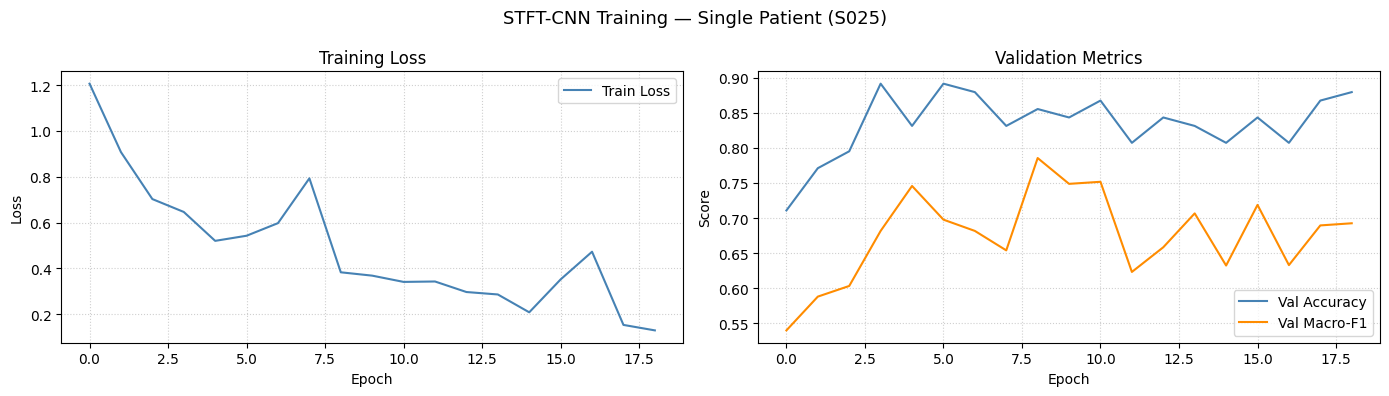

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(history['val_acc'],  label='Val Accuracy',  color='steelblue')
axes[1].plot(history['val_f1'],   label='Val Macro-F1',  color='darkorange')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('STFT-CNN Training — Single Patient (S025)', fontsize=13)
plt.tight_layout()
plt.show()


Graph — Confusion Matrix & Hypnogram

=== Single Patient Test Results ===
Accuracy              : 0.7697
Cohen's Kappa         : 0.6583
Macro-F1 (all 5 cls)  : 0.5356
Macro-F1 (present 4 cls): 0.6695
              precision    recall  f1-score   support

           W       0.86      0.88      0.87        43
          N1       0.09      0.25      0.13         8
          N2       0.93      0.71      0.80        89
          N3       0.00      0.00      0.00         0
           R       0.80      0.96      0.87        25

   micro avg       0.77      0.77      0.77       165
   macro avg       0.54      0.56      0.54       165
weighted avg       0.85      0.77      0.80       165



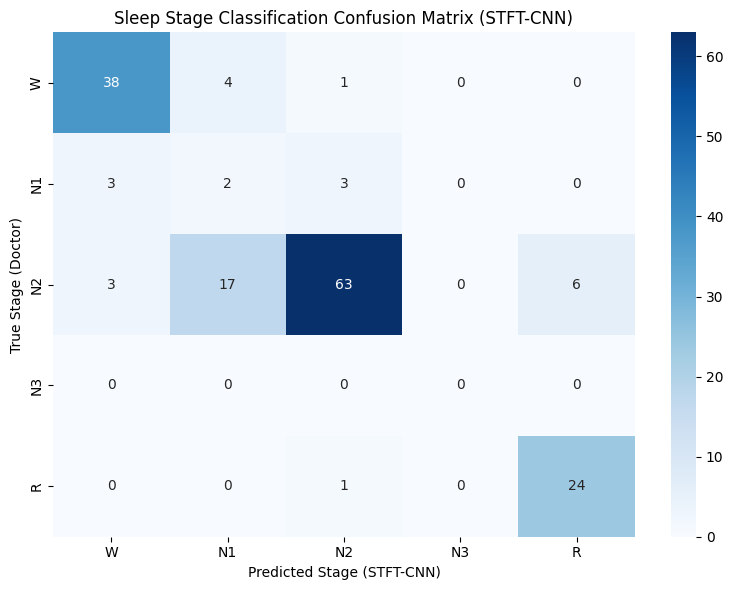

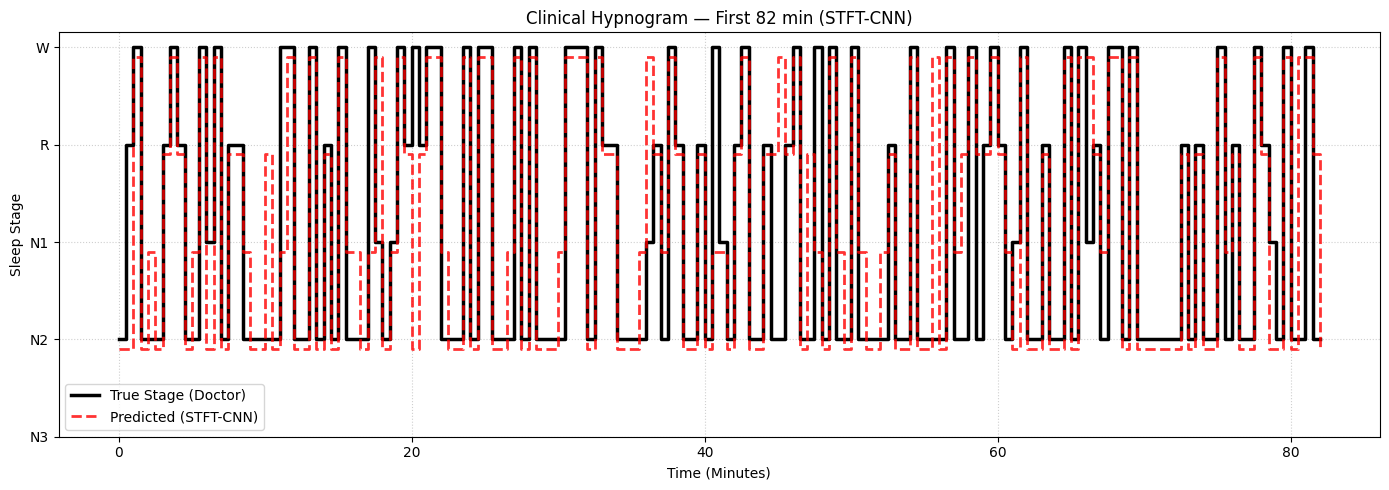

In [ ]:
def evaluate_and_plot(model, loader, title_suffix=''):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            out = model(X_batch.to(DEVICE))
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y_batch.numpy())

    preds, trues = np.array(preds), np.array(trues)
    present      = sorted(np.unique(trues).tolist())
    acc          = accuracy_score(trues, preds)
    kappa        = cohen_kappa_score(trues, preds)
    macro_f1_5   = f1_score(trues, preds, labels=[0,1,2,3,4], average='macro', zero_division=0)
    macro_f1_pre = f1_score(trues, preds, labels=present,     average='macro', zero_division=0)

    print(f"Accuracy              : {acc:.4f}")
    print(f"Cohen's Kappa         : {kappa:.4f}")
    print(f"Macro-F1 (all 5 cls)  : {macro_f1_5:.4f}")
    print(f"Macro-F1 (present {len(present)} cls): {macro_f1_pre:.4f}")

    print(classification_report(trues, preds,
          labels=[0,1,2,3,4],                
          target_names=['W','N1','N2','N3','R'],
          zero_division=0))


    labels = ['W', 'N1', 'N2', 'N3', 'R']

    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(trues, preds, labels=[0,1,2,3,4])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Sleep Stage Classification Confusion Matrix{title_suffix}')
    plt.xlabel('Predicted Stage (STFT-CNN)')
    plt.ylabel('True Stage (Doctor)')
    plt.tight_layout()
    plt.show()

    # Hypnogram
    clinical_order  = [0, 4, 1, 2, 3]
    clinical_labels = ['W', 'R', 'N1', 'N2', 'N3']
    y_true_c = [-clinical_order.index(v) for v in trues]
    y_pred_c = [-clinical_order.index(v) for v in preds]

    display_length = min(600, len(trues))
    time_axis      = np.arange(display_length) * 0.5  

    plt.figure(figsize=(14, 5))
    plt.step(time_axis, y_true_c[:display_length],
             label='True Stage (Doctor)', color='black', linewidth=2.5, where='post')
    plt.step(time_axis, [y - 0.1 for y in y_pred_c[:display_length]],
             label='Predicted (STFT-CNN)', color='red',
             linestyle='--', linewidth=2, where='post', alpha=0.8)
    plt.yticks([-0,-1,-2,-3,-4], clinical_labels)
    plt.title(f'Clinical Hypnogram — First {display_length*0.5:.0f} min{title_suffix}')
    plt.xlabel('Time (Minutes)')
    plt.ylabel('Sleep Stage')
    plt.legend(loc='lower left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return preds, trues, acc, macro_f1_5, macro_f1_pre

print("=== Single Patient Test Results ===")
preds_test, trues_test, test_acc, test_f1_5, test_f1_pre = evaluate_and_plot(
    model, test_loader, title_suffix=' (STFT-CNN)')


# 3. Cross Patient Training
Selected patient at average for validation

In [16]:
info_df = pd.read_csv('./dataset/participant_info.csv', dtype=str)
info_df['SID'] = info_df['SID'].astype(str).str.strip()
info_df = info_df.dropna(subset=['SID'])
info_df = info_df[info_df['SID'].str.lower() != 'nan']
info_df = info_df[info_df['SID'] != '']

phys_features = ['AGE', 'BMI', 'OAHI', 'AHI', 'Mean_SaO2', 'Arousal Index']
if 'Mean_SaO2' in info_df.columns:
    info_df['Mean_SaO2'] = info_df['Mean_SaO2'].astype(str).str.replace('%', '', regex=False)
for col in phys_features:
    info_df[col] = pd.to_numeric(info_df[col], errors='coerce')

global_means = info_df[phys_features].mean()
global_stds  = info_df[phys_features].std()

def calc_distance(row):
    return np.sqrt(sum(
        ((row[c] - global_means[c]) / global_stds[c]) ** 2
        for c in phys_features if not pd.isna(row[c])
    ))

info_df['Distance_to_Centroid'] = info_df.apply(calc_distance, axis=1)
top5 = info_df.sort_values('Distance_to_Centroid').head(5)
print("--- Top 5 average patients ---")
print(top5[['SID'] + phys_features + ['Distance_to_Centroid']])


--- Top 5 average patients ---
     SID    AGE   BMI  OAHI  AHI  Mean_SaO2  Arousal Index  \
22  S081  55.35  37.0    17   18         94             32   
48  S054  60.41  37.0    24   24         93             43   
87  S014  51.94  32.0    20   21         96             44   
12  S091  51.01  31.0     9   10         95             38   
84  S017  58.08  32.0     9   30         96             47   

    Distance_to_Centroid  
22              0.482939  
48              0.638148  
87              0.739632  
12              0.778345  
84              0.882759  


Process single patient — StandardScaler + STFT windowing

In [17]:
def process_patient_stft(sid, data_dir='./dataset/', window_size=1920):
    """读取单患者 CSV → StandardScaler → STFT 窗口化"""
    print(f"--- Processing {sid} ---")
    fp  = os.path.join(data_dir, f'{sid}_whole_df.csv')
    df_ = pd.read_csv(fp)

    feat_cols = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
    label_c   = 'Sleep_Stage'

    miss = df_[feat_cols].isna().sum().sum()
    print(f"  Missing before: {miss}")
    df_[feat_cols] = df_[feat_cols].interpolate(method='linear', limit_direction='both')
    print(f"  Missing after:  {df_[feat_cols].isna().sum().sum()}")

    scaler = StandardScaler()
    df_[feat_cols] = scaler.fit_transform(df_[feat_cols])
    return df_

def create_windows_stft_from_df(df_, window_size=1920):
    feat_cols = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']
    label_c   = 'Sleep_Stage'
    n         = len(df_) // window_size
    X_list, y_list = [], []

    for i in range(n):
        s, e        = i * window_size, (i + 1) * window_size
        w           = df_.iloc[s:e]
        mode_series = w[label_c].mode()
        if mode_series.empty: continue
        label = mode_series.iloc[0]
        if str(label).strip() in ['P', 'Missing']: continue

        stft_t = compute_stft_window(w[feat_cols].values)
        X_list.append(stft_t)
        y_list.append(label)

    return np.array(X_list), np.array(y_list)


Declare train / val / test sets — **同 TimesNet notebook 的患者分组**

In [ ]:
test_healthy_sid = 'S049'
test_severe_sid  = 'S072'
test_avg_sid     = 'S014'

val_sids_cross = ['S011', 'S029']

train_sids = ['S005', 'S007', 'S010', 'S025', 'S028', 'S033',
              'S050', 'S054', 'S066', 'S067', 'S081',
              'S095', 'S100',
              'S074', 'S052', 'S087',
              'S099', 'S064', 'S031']

print(f"Train: {len(train_sids)} patients")
print(f"Val:   {val_sids_cross}")
print(f"Test:  {test_avg_sid}(avg) / {test_healthy_sid}(healthy) / {test_severe_sid}(severe)\n")

print("--- Processing test patients ---")
df_healthy = process_patient_stft(test_healthy_sid)
df_severe  = process_patient_stft(test_severe_sid)
df_avg     = process_patient_stft(test_avg_sid)

print("--- Processing val patients (held-out) ---")
val_dfs = {sid: process_patient_stft(sid) for sid in val_sids_cross}

print("--- Processing train patients ---")
train_dfs = {sid: process_patient_stft(sid) for sid in train_sids}

Train: 19 patients
Val:   ['S011', 'S029']
Test:  S014(avg) / S049(healthy) / S072(severe)

--- Processing test patients ---
--- Processing S049 ---
  Missing before: 426
  Missing after:  0
--- Processing S072 ---
  Missing before: 2070
  Missing after:  0
--- Processing S014 ---
  Missing before: 3195
  Missing after:  0
--- Processing val patients (held-out) ---
--- Processing S011 ---
  Missing before: 657
  Missing after:  0
--- Processing S029 ---
  Missing before: 1866
  Missing after:  0
--- Processing train patients ---
--- Processing S005 ---
  Missing before: 148
  Missing after:  0
--- Processing S007 ---
  Missing before: 20183
  Missing after:  0
--- Processing S010 ---
  Missing before: 20211
  Missing after:  0
--- Processing S025 ---
  Missing before: 2488
  Missing after:  0
--- Processing S028 ---
  Missing before: 289
  Missing after:  0
--- Processing S033 ---
  Missing before: 257
  Missing after:  0
--- Processing S050 ---
  Missing before: 5730
  Missing after: 

Slice all patients into STFT windows

In [ ]:
label_map = {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'R': 4}
def encode(y_arr): return np.array([label_map[l] for l in y_arr])

print(f"Train patients: {train_sids}")

print("--- Slicing test patients ---")
X_healthy, y_healthy_raw = create_windows_stft_from_df(df_healthy)
X_severe,  y_severe_raw  = create_windows_stft_from_df(df_severe)
X_avg,     y_avg_raw     = create_windows_stft_from_df(df_avg)
y_healthy_enc = encode(y_healthy_raw)
y_severe_enc  = encode(y_severe_raw)
y_avg_enc     = encode(y_avg_raw)

print("\n--- Slicing val patients (held-out) ---")
val_X_parts, val_y_parts = [], []
for sid in val_sids_cross:
    Xv, yv_raw = create_windows_stft_from_df(val_dfs[sid])
    val_X_parts.append(Xv)
    val_y_parts.append(encode(yv_raw))
    print(f"  {sid}: {len(yv_raw)} val windows, classes={list(np.unique(encode(yv_raw)))}")
X_val     = np.concatenate(val_X_parts)
y_val_enc = np.concatenate(val_y_parts)

print("\n--- Slicing train patients ---")
train_X_parts, train_y_parts = [], []
for sid in train_sids:
    Xt, yt_raw = create_windows_stft_from_df(train_dfs[sid])
    yt = encode(yt_raw)
    train_X_parts.append(Xt)
    train_y_parts.append(yt)
    print(f"  {sid}: {len(yt)} train windows (classes={list(np.unique(yt))})")

X_train     = np.concatenate(train_X_parts)
y_train_enc = np.concatenate(train_y_parts)

norm_mean_c, norm_std_c = compute_norm_stats(X_train)
X_train   = apply_norm(X_train,   norm_mean_c, norm_std_c)
X_val     = apply_norm(X_val,     norm_mean_c, norm_std_c)
X_avg     = apply_norm(X_avg,     norm_mean_c, norm_std_c)
X_healthy = apply_norm(X_healthy, norm_mean_c, norm_std_c)
X_severe  = apply_norm(X_severe,  norm_mean_c, norm_std_c)
print("\n[cross] train mean≈0 check:",
      round(float(X_train.mean()), 4), "std≈1 check:", round(float(X_train.std()), 4))

print(f"\nX_train: {X_train.shape}  y_train: {y_train_enc.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val_enc.shape}")
print(f"X_avg:   {X_avg.shape}    X_healthy: {X_healthy.shape}    X_severe: {X_severe.shape}")

Train patients: ['S005', 'S007', 'S010', 'S025', 'S028', 'S033', 'S050', 'S054', 'S066', 'S067', 'S081', 'S095', 'S100', 'S074', 'S052', 'S087', 'S099', 'S064', 'S031']
--- Slicing test patients ---

--- Slicing val patients (held-out) ---
  S011: 813 val windows, classes=[0, 1, 2, 3, 4]
  S029: 804 val windows, classes=[0, 1, 2]

--- Slicing train patients ---
  S005: 733 train windows (classes=[0, 1, 2, 3, 4])
  S007: 821 train windows (classes=[0, 1, 2, 3, 4])
  S010: 824 train windows (classes=[0, 1, 2, 4])
  S025: 825 train windows (classes=[0, 1, 2, 4])
  S028: 798 train windows (classes=[0, 1, 2, 3, 4])
  S033: 798 train windows (classes=[0, 1, 2, 3, 4])
  S050: 719 train windows (classes=[0, 1, 2, 3, 4])
  S054: 799 train windows (classes=[0, 1, 2, 3])
  S066: 758 train windows (classes=[0, 1, 2, 3, 4])
  S067: 829 train windows (classes=[0, 1, 2, 4])
  S081: 730 train windows (classes=[0, 1, 2, 3])
  S095: 820 train windows (classes=[0, 1, 2, 3])
  S100: 862 train windows (cla

Check label distribution — 与 TimesNet notebook 相同的统计方式

In [20]:
def check_dist(y_arr, name):
    counts = Counter(y_arr)
    rev    = {0:'W',1:'N1',2:'N2',3:'N3',4:'R'}
    total  = len(y_arr)
    print(f"--- {name} ---")
    for k in range(5):
        c = counts.get(k, 0)
        print(f"  {rev[k]} ({k}): {c:5d} ({c/total*100:5.1f}%)")
    print(f"  Total: {total}\n")

Save cross-patient data & build loaders

In [21]:
save_dir = './dataset/stft_cross_ready/'
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, 'X_train.npy'),   X_train)
np.save(os.path.join(save_dir, 'y_train.npy'),   y_train_enc)
np.save(os.path.join(save_dir, 'X_val.npy'),     X_val)
np.save(os.path.join(save_dir, 'y_val.npy'),     y_val_enc)
np.save(os.path.join(save_dir, 'X_test.npy'),    X_avg)
np.save(os.path.join(save_dir, 'y_test.npy'),    y_avg_enc)
print("Cross-patient data saved.")

BATCH = 32
train_loader_c = DataLoader(STFTDataset(X_train, y_train_enc), BATCH, shuffle=True)
val_loader_c   = DataLoader(STFTDataset(X_val,   y_val_enc),   BATCH, shuffle=False)
loader_avg     = DataLoader(STFTDataset(X_avg,     y_avg_enc),     BATCH, shuffle=False)
loader_healthy = DataLoader(STFTDataset(X_healthy, y_healthy_enc), BATCH, shuffle=False)
loader_severe  = DataLoader(STFTDataset(X_severe,  y_severe_enc),  BATCH, shuffle=False)
print("Loaders ready.")


Cross-patient data saved.
Loaders ready.


In [22]:
weights_c = torch.tensor([1.0, 2.0, 0.35, 1.1, 0.9], dtype=torch.float32)
print("[physiological-prior] W/N1/N2/N3/R =", weights_c.tolist())

criterion_c = nn.CrossEntropyLoss(weight=weights_c.to(DEVICE))

[physiological-prior] W/N1/N2/N3/R = [1.0, 2.0, 0.3499999940395355, 1.100000023841858, 0.8999999761581421]


Train cross-patient model

In [23]:
model_c   = STFTSleepNet().to(DEVICE)
optimizer_c = optim.Adam(model_c.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_c = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_c, mode='max', factor=0.5, patience=3, verbose=True)

EPOCHS   = 50
PATIENCE = 10

best_val_f1_c = 0
best_state_c  = None
patience_cnt  = 0
history_c     = {'train_loss': [], 'val_acc': [], 'val_f1': []}

print("Starting cross-patient training...")
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model_c.train()
    total_loss = 0
    for X_b, y_b in train_loader_c:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer_c.zero_grad()
        loss = criterion_c(model_c(X_b), y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model_c.parameters(), 1.0)
        optimizer_c.step()
        total_loss += loss.item()

    model_c.eval()
    preds_v, trues_v = [], []
    with torch.no_grad():
        for X_b, y_b in val_loader_c:
            out = model_c(X_b.to(DEVICE))
            preds_v.extend(out.argmax(1).cpu().numpy())
            trues_v.extend(y_b.numpy())

    val_acc = accuracy_score(trues_v, preds_v)
    val_f1  = f1_score(trues_v, preds_v, average='macro', zero_division=0)
    scheduler_c.step(val_f1)

    history_c['train_loss'].append(total_loss / len(train_loader_c))
    history_c['val_acc'].append(val_acc)
    history_c['val_f1'].append(val_f1)

    print(f"Epoch {epoch:3d} | Loss {total_loss/len(train_loader_c):.4f} | "
          f"Val Acc {val_acc:.4f} | Val Macro-F1 {val_f1:.4f}")

    if val_f1 > best_val_f1_c:
        best_val_f1_c = val_f1
        best_state_c  = {k: v.clone() for k, v in model_c.state_dict().items()}
        patience_cnt  = 0
        print(f"  ✓ Best model saved (F1={val_f1:.4f})")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model_c.load_state_dict(best_state_c)
print(f"\nDone in {time.time()-t0:.1f}s")


Starting cross-patient training...


C:\Users\15810\anaconda3\envs\timesnet\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch   1 | Loss 1.3538 | Val Acc 0.2814 | Val Macro-F1 0.1709
  ✓ Best model saved (F1=0.1709)
Epoch   2 | Loss 1.2335 | Val Acc 0.3061 | Val Macro-F1 0.1737
  ✓ Best model saved (F1=0.1737)
Epoch   3 | Loss 1.1563 | Val Acc 0.2010 | Val Macro-F1 0.1316
Epoch   4 | Loss 1.0919 | Val Acc 0.3673 | Val Macro-F1 0.2083
  ✓ Best model saved (F1=0.2083)
Epoch   5 | Loss 1.0321 | Val Acc 0.2814 | Val Macro-F1 0.1634
Epoch   6 | Loss 0.9712 | Val Acc 0.2987 | Val Macro-F1 0.1840
Epoch   7 | Loss 0.9301 | Val Acc 0.2418 | Val Macro-F1 0.1537
Epoch   8 | Loss 0.8991 | Val Acc 0.3253 | Val Macro-F1 0.1881
Epoch   9 | Loss 0.8120 | Val Acc 0.3414 | Val Macro-F1 0.2042
Epoch  10 | Loss 0.7795 | Val Acc 0.2313 | Val Macro-F1 0.1591
Epoch  11 | Loss 0.7602 | Val Acc 0.3333 | Val Macro-F1 0.2021
Epoch  12 | Loss 0.7420 | Val Acc 0.2597 | Val Macro-F1 0.1625
Epoch  13 | Loss 0.6782 | Val Acc 0.3939 | Val Macro-F1 0.2166
  ✓ Best model saved (F1=0.2166)
Epoch  14 | Loss 0.6541 | Val Acc 0.3185 | Val Ma

Test with average patient (S014)

=== Test Avg (S014) ===
Accuracy              : 0.3945
Cohen's Kappa         : 0.0611
Macro-F1 (all 5 cls)  : 0.1881
Macro-F1 (present 5 cls): 0.1881
              precision    recall  f1-score   support

           W       0.52      0.14      0.22       195
          N1       0.07      0.52      0.13        31
          N2       0.57      0.63      0.60       431
          N3       0.00      0.00      0.00       106
           R       0.00      0.00      0.00        33

    accuracy                           0.39       796
   macro avg       0.23      0.26      0.19       796
weighted avg       0.44      0.39      0.38       796



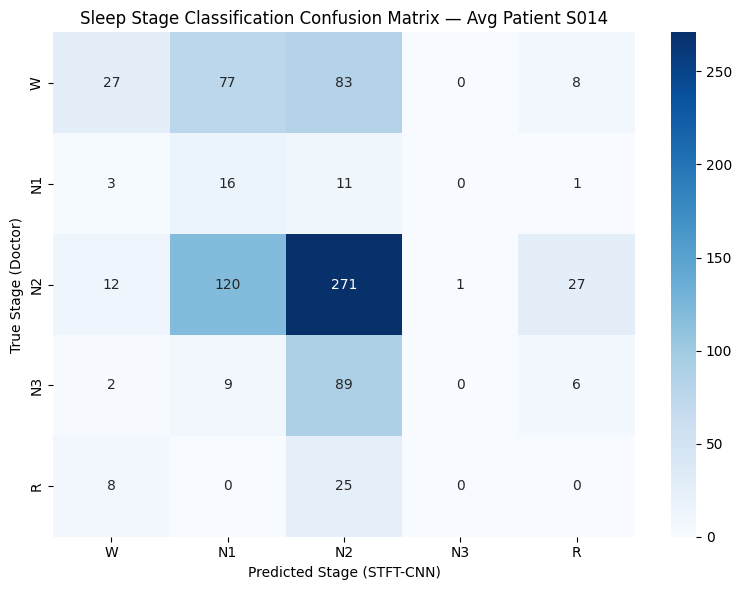

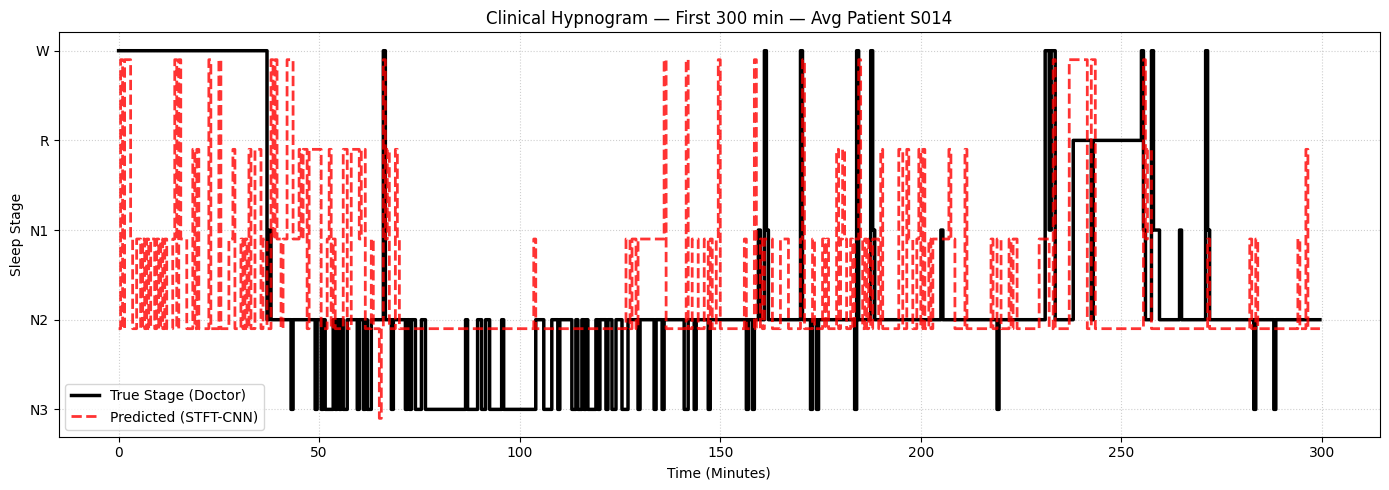

(array([2, 0, 2, 0, 0, 0, 1, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1,
        2, 1, 2, 2, 2, 1, 0, 2, 0, 1, 1, 1, 2, 2, 2, 4, 2, 4, 2, 2, 2, 2,
        2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 1, 1, 4, 2, 2, 2, 1, 2, 1, 2, 4,
        2, 2, 4, 4, 4, 2, 1, 1, 2, 2, 0, 1, 0, 1, 1, 2, 1, 1, 0, 0, 0, 1,
        1, 1, 4, 1, 4, 4, 2, 4, 4, 4, 4, 4, 4, 2, 2, 2, 1, 4, 2, 1, 2, 2,
        2, 2, 4, 4, 2, 2, 4, 4, 4, 4, 1, 4, 4, 2, 2, 2, 1, 2, 2, 2, 3, 2,
        0, 1, 4, 2, 2, 2, 4, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
        1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 

In [24]:
print("=== Test Avg (S014) ===")
evaluate_and_plot(model_c, loader_avg, title_suffix=' — Avg Patient S014')


Test with healthy patient (S049)

=== Test Healthy (S049) ===
Accuracy              : 0.3640
Cohen's Kappa         : 0.0863
Macro-F1 (all 5 cls)  : 0.1971
Macro-F1 (present 4 cls): 0.2463
              precision    recall  f1-score   support

           W       0.27      0.43      0.33       141
          N1       0.01      0.14      0.02        22
          N2       0.80      0.40      0.53       546
          N3       0.00      0.00      0.00         0
           R       0.12      0.08      0.10        85

   micro avg       0.36      0.36      0.36       794
   macro avg       0.24      0.21      0.20       794
weighted avg       0.61      0.36      0.44       794



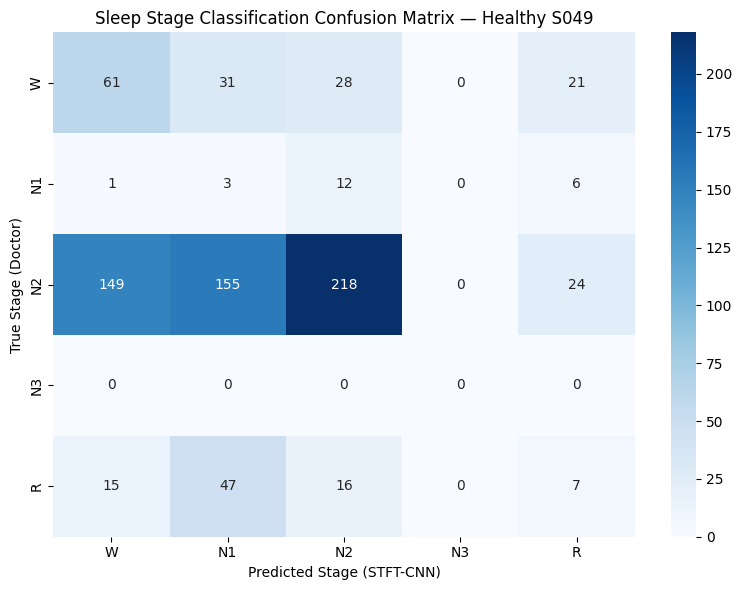

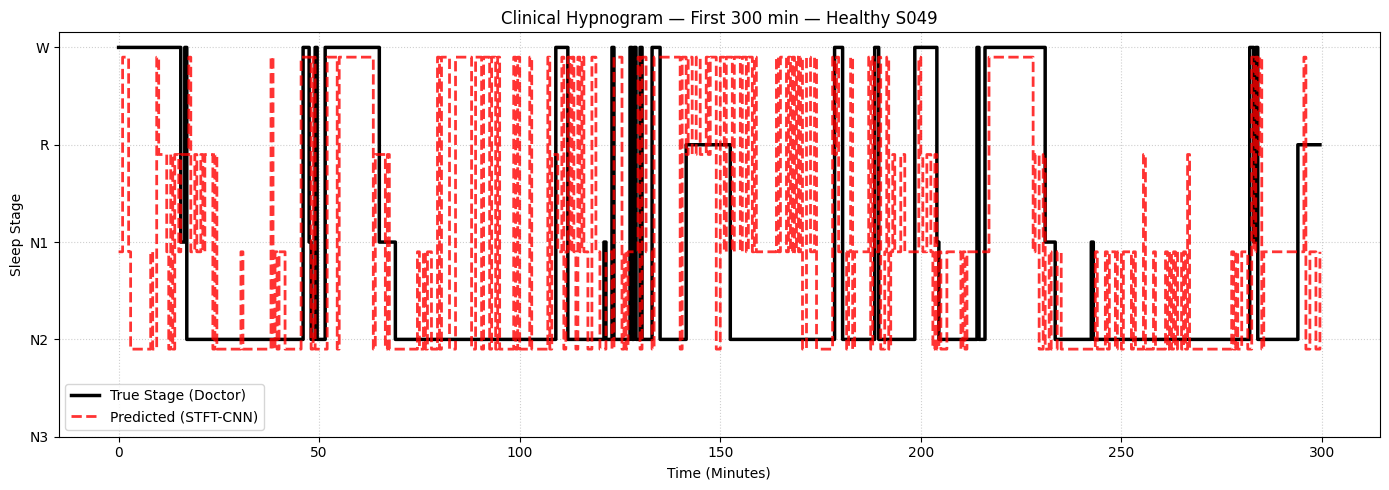

(array([1, 1, 0, 0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 0, 4, 4,
        4, 4, 1, 2, 4, 2, 4, 4, 1, 4, 4, 4, 4, 0, 1, 1, 4, 1, 1, 4, 1, 4,
        4, 4, 4, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2,
        2, 2, 2, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4,
        4, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2,
        1, 1, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0,
        2, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0,
        2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 4, 4, 4, 1,
        1, 0, 2, 1, 0, 1, 0, 1, 2, 0, 1, 0, 1, 1, 2, 2, 0, 0, 1, 1, 2, 2,
        2, 1, 1, 1, 2, 0, 0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1, 0, 2, 0, 0, 1,
        1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 4, 0, 0,
        4, 4, 0, 0, 4, 4, 4, 0, 4, 0, 

In [ ]:
print("=== Test Healthy (S049) ===")
evaluate_and_plot(model_c, loader_healthy, title_suffix=' — Healthy S049')

Test with severe patient (S072)

=== Test Severe (S072) ===
Accuracy              : 0.4754
Cohen's Kappa         : 0.2155
Macro-F1 (all 5 cls)  : 0.2487
Macro-F1 (present 3 cls): 0.4146
              precision    recall  f1-score   support

           W       0.90      0.47      0.62       437
          N1       0.21      0.18      0.19       134
          N2       0.31      0.73      0.43       161
          N3       0.00      0.00      0.00         0
           R       0.00      0.00      0.00         0

    accuracy                           0.48       732
   macro avg       0.28      0.28      0.25       732
weighted avg       0.64      0.48      0.50       732



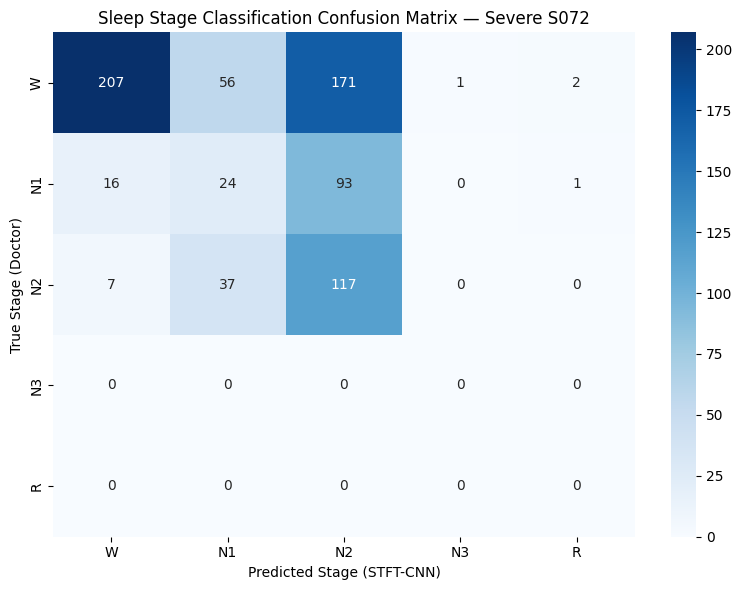

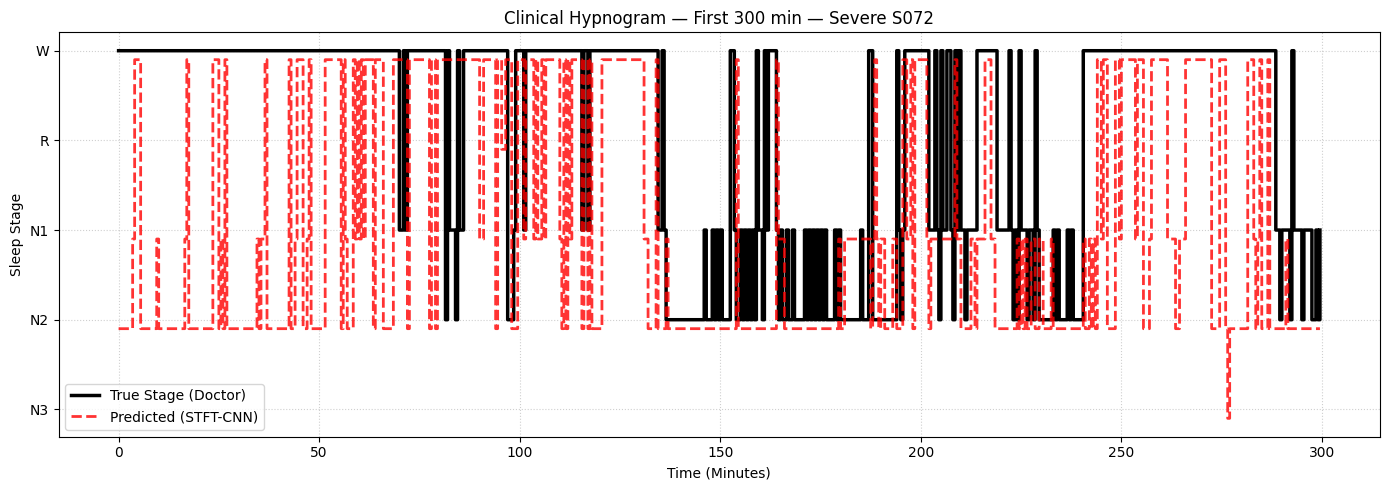

(array([2, 2, 2, 2, 2, 2, 2, 1, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 0, 0, 0, 2, 1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 1, 2, 1, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
        1, 0, 0, 0, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0,
        0, 2, 0, 1, 2, 2, 2, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0,
        2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 4, 4, 0, 0, 0, 2, 2,
        2, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        1, 2, 0, 2, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 2, 2, 2, 2, 2, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
        2, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

In [ ]:
print("=== Test Severe (S072) ===")
evaluate_and_plot(model_c, loader_severe, title_suffix=' — Severe S072')

## Summary — Comparison Table
与 TimesNet 对比用的汇总表

In [27]:
results = {}
for name, loader in [('Avg S014',     loader_avg),
                     ('Healthy S049', loader_healthy),
                     ('Severe S072',  loader_severe)]:
    model_c.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            out = model_c(X_b.to(DEVICE))
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y_b.numpy())
    preds, trues = np.array(preds), np.array(trues)
    results[name] = {
        'Accuracy':  round(accuracy_score(trues, preds), 4),
        'Macro-F1':  round(f1_score(trues, preds, average='macro', zero_division=0), 4),
    }

print("\n" + "="*50)
print(f"{'Test Set':<18} {'Accuracy':>10} {'Macro-F1':>10}")
print("-"*40)
for name, r in results.items():
    print(f"{name:<18} {r['Accuracy']:>10.4f} {r['Macro-F1']:>10.4f}")
print("="*50)




Test Set             Accuracy   Macro-F1
----------------------------------------
Avg S014               0.3945     0.1881
Healthy S049           0.3640     0.2463
Severe S072            0.4754     0.2487


Save model

In [28]:
os.makedirs('./stft_results', exist_ok=True)
torch.save(best_state_c, './stft_results/stft_cnn_best.pt')
print("Model saved to ./stft_results/stft_cnn_best.pt")


Model saved to ./stft_results/stft_cnn_best.pt


In [ ]:
import copy
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

FEATURE_NAMES = ['BVP', 'IBI', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR']

TEST_SETS = {
    'Avg S014':     (X_avg,     y_avg_enc),
    'Healthy S049': (X_healthy, y_healthy_enc),
    'Severe S072':  (X_severe,  y_severe_enc),
}

def train_eval_channels(keep_idx, epochs=40, patience=8, seed=42):
    """keep_idx: 保留的通道索引 list, 如 [0,1,2,3,4,5,6,7] 或 [1](只留IBI)"""
    torch.manual_seed(seed); np.random.seed(seed)

    Xtr = X_train[:, keep_idx, :, :]     
    Xv  = X_val[:,   keep_idx, :, :]
    in_ch = len(keep_idx)

    tr_loader = DataLoader(STFTDataset(Xtr, y_train_enc), batch_size=32, shuffle=True)
    v_loader  = DataLoader(STFTDataset(Xv,  y_val_enc),   batch_size=32, shuffle=False)

    weights_tensor = torch.tensor([1.0, 2.0, 0.35, 1.1, 0.9], dtype=torch.float32)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(DEVICE))
    
    model = STFTSleepNet(in_channels=in_ch).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)

    best_f1, best_state, cnt = 0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval(); pv, tv = [], []
        with torch.no_grad():
            for Xb, yb in v_loader:
                out = model(Xb.to(DEVICE))
                pv.extend(out.argmax(1).cpu().numpy()); tv.extend(yb.numpy())
        vf1 = f1_score(tv, pv, average='macro', zero_division=0)
        sched.step(vf1)
        if vf1 > best_f1:
            best_f1, best_state, cnt = vf1, copy.deepcopy(model.state_dict()), 0
        else:
            cnt += 1
            if cnt >= patience: break
    model.load_state_dict(best_state)

    res = {}
    model.eval()
    for name, (Xt, yt) in TEST_SETS.items():
        loader = DataLoader(STFTDataset(Xt[:, keep_idx, :, :], yt), batch_size=32, shuffle=False)
        p, t = [], []
        with torch.no_grad():
            for Xb, yb in loader:
                out = model(Xb.to(DEVICE))
                p.extend(out.argmax(1).cpu().numpy()); t.extend(yb.numpy())
        res[name] = f1_score(t, p, average='macro', zero_division=0)
    res['Val'] = best_f1
    return res

In [ ]:
all_idx  = list(range(8))
avg_cols = ['Avg S014', 'Healthy S049', 'Severe S072']

print("Running baseline (all 8 channels)...")
base = train_eval_channels(all_idx)
base_mean = np.mean([base[c] for c in avg_cols])

print("Running leave-one-out...")
loo_rows = []
for c in range(8):
    r = train_eval_channels([i for i in all_idx if i != c])
    r['Dropped'] = FEATURE_NAMES[c]
    loo_rows.append(r)

print("Running single-channel...")
sc_rows = []
for c in range(8):
    r = train_eval_channels([c])
    r['Only'] = FEATURE_NAMES[c]
    sc_rows.append(r)

print(f"\n=== BASELINE (all 8 ch) === 三测试集平均 Macro-F1 = {base_mean:.4f}")
for c in avg_cols: print(f"  {c}: {base[c]:.4f}")

df_loo = pd.DataFrame(loo_rows)
df_loo['Mean']  = df_loo[avg_cols].mean(axis=1)
df_loo['Delta'] = df_loo['Mean'] - base_mean       
df_loo = df_loo.sort_values('Delta')
print("\n=== LEAVE-ONE-OUT (去掉该通道后) ===")
print("Delta 越负 = 去掉后掉得越多 = 该通道越不可替代")
print(df_loo[['Dropped'] + avg_cols + ['Mean', 'Delta']].round(4).to_string(index=False))

df_sc = pd.DataFrame(sc_rows)
df_sc['Mean'] = df_sc[avg_cols].mean(axis=1)
df_sc = df_sc.sort_values('Mean', ascending=False)
print("\n=== SINGLE-CHANNEL (只用该通道) ===")
print("Mean 越高 = 该通道单独信息量越大 (随机基线约 0.15-0.20)")
print(df_sc[['Only'] + avg_cols + ['Mean']].round(4).to_string(index=False))

Running baseline (all 8 channels)...
Running leave-one-out...
Running single-channel...

=== BASELINE (all 8 ch) === 三测试集平均 Macro-F1 = 0.2371
  Avg S014: 0.1662
  Healthy S049: 0.2419
  Severe S072: 0.3033

=== LEAVE-ONE-OUT (去掉该通道后) ===
Delta 越负 = 去掉后掉得越多 = 该通道越不可替代
Dropped  Avg S014  Healthy S049  Severe S072   Mean   Delta
    BVP    0.1866        0.1899       0.2466 0.2077 -0.0294
   TEMP    0.1791        0.2250       0.2772 0.2271 -0.0100
  ACC_Y    0.2137        0.2502       0.2491 0.2377  0.0005
  ACC_X    0.2305        0.2750       0.2229 0.2428  0.0057
    IBI    0.1888        0.2624       0.3120 0.2544  0.0173
     HR    0.2458        0.1811       0.3666 0.2645  0.0274
  ACC_Z    0.2109        0.2794       0.3092 0.2665  0.0294
    EDA    0.2286        0.2744       0.3230 0.2753  0.0382

=== SINGLE-CHANNEL (只用该通道) ===
Mean 越高 = 该通道单独信息量越大 (随机基线约 0.15-0.20)
 Only  Avg S014  Healthy S049  Severe S072   Mean
ACC_Z    0.2498        0.3585       0.3863 0.3315
  BVP    0.1733      